# Efficiency comparison of s-stage IRKGL schemes ( (6-Body Solar System)

Running the code cells below will compute and automatically generate the following figures:

-  **From Section 5.2**:

    - **Figure 2(a)**, saved as **`Fig3.pdf`**
    - **Figure 2(b)**, saved as **`Fig4.pdf`**


<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Initial-value-problem:-6-body-problem-(outer-solar-system)">Initial value problem: 6-body problem (outer solar system)</a></li> 
    <li><a href="#IRKGL16-integrations">IRKGL16 integrations</a></li>
    <li><a href="#Figures">Figures</a></li>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
using BenchmarkTools
using IRKGaussLegendre

Base.@boundscheck false
pkgversion(IRKGaussLegendre) # must be v"0.2.13" or greater

v"0.2.13"

### Utils

In [2]:
mutable struct tsolutions_IRKGL16
    dts
    sols
    retcodes
    iters
    cpus
    fcns
    MaxΔHglobal
    MaxΔHlocal
    wcpu
    cpu_idx
end

function run_many_IRKGL16(alg, prob, ddt0, HAM; wcpu=true)

    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    iters=zero(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]
    
    sols=Array{IRKGaussLegendre.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B,parms_B)
    
    for i in 1:length(ddt0)
        
        print(",",ddt0[i])    
        dt0=ddt0[i]
        
        sols[i]=solve(prob,alg,dt=dt0, adaptive=false)
        if sols[i].retcode==ReturnCode.Success
           iters[i]=sols[i].stats.nfpiter
           fcns[i]=iters[i]*8
        else
           retcodes[i]=false
           iters[i]=Inf
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solve(prob,alg, dt=dt0, adaptive=false, save_everystep = false)
            cpus[i]= @belapsed solve($prob,$alg, dt=$dt0, adaptive=false, save_everystep = false)
        end
        
    end

    println("")
    return tsolutions_IRKGL16(ddt0, sols,retcodes,iters,cpus,fcns,MaxΔHglobal,MaxΔHlocal,wcpu,-1)

end  

run_many_IRKGL16 (generic function with 1 method)

##### <a href="#top">Back to the top</a>

## Initial value problem: 6-body problem (outer solar system)

In Nbody.jl below, the following functions are defined: NbodyEnergy(u,Gm), NbodyODE!(du,u,Gm,t), and NbodyODE1!(du,u,Gm,t), where

\begin{equation*}
u = 
\left(\begin{matrix}
q_1  & v_1\\
\vdots & \vdots \\
q_N  & v_N
\end{matrix}
\right) \in \mathbb{R}^{2 \times 3\times N}, \quad
Gm = (G\,  m_1, \ldots,G\,  m_N) \in \mathbb{R}^N.
\end{equation*}

The energy, as a function of the positions $q_1,\ldots,q_N \in \mathbb{R}^3$ and the velocities $v_1,\ldots,v_N \in \mathbb{R}^3$ of the $N$ bodies is:
\begin{equation*}
\begin{split}
\mathrm{Energy}(q_1,\ldots,q_N,v_1,\ldots,v_N) = 
\frac12 \sum_{i=1}^{N} m_i \, \|v_i\|^2
- G \sum_{1\leq i < j \leq N} \frac{m_i m_j}{\|q_i-q_j\|}.
\end{split}
\end{equation*}


The ODE system of the N-body problem,
as a function of the positions $q_1,\ldots,q_N \in \mathbb{R}^3$ and the velocities $v_1,\ldots,v_N \in \mathbb{R}^3$ of the $N$ bodies is:
\begin{equation*}
\begin{split}
\frac{d}{dt} q_i &= v_i, \\
\frac{d}{dt} v_i &= G\, 
\sum_{j \neq i} \frac{m_j}{\|q_j-q_i\|^3}\,
(q_j-q_i).
\end{split}
\end{equation*}
This system of ODEs can be writen in compact form as
\begin{equation*}
\frac{d u}{dt} = f(t,u,Gm)
\end{equation*}




In [3]:
function NbodyEnergy(u,Gm)
     N = length(Gm)
     zerouel = zero(eltype(u))
     T = zerouel
     U = zerouel
     for i in 1:N
        qi = u[:,i,1]
        vi = u[:,i,2]
        Gmi = Gm[i]
        T += Gmi*(vi[1]*vi[1]+vi[2]*vi[2]+vi[3]*vi[3])
        for j in (i+1):N
           qj = u[:,j,1]
           Gmj = Gm[j]
           qij = qi - qj
           U -= Gmi*Gmj/norm(qij)
        end
     end
    1/2*T + U
end


function NbodyODE!(F,u,Gm,t)
   N = length(Gm)
   for i in 1:N
      for k in 1:3
          F[k, i, 2] = 0
      end
   end
   for i in 1:N
      xi = u[1,i,1]
      yi = u[2,i,1]
      zi = u[3,i,1]
      Gmi = Gm[i]
      for j in i+1:N
          xij = xi - u[1,j,1]
          yij = yi - u[2,j,1]
          zij = zi - u[3,j,1]
          Gmj = Gm[j]
          dotij = (xij*xij+yij*yij+zij*zij)
          auxij = 1/(sqrt(dotij)*dotij)
          Gmjauxij = Gmj*auxij
          F[1,i,2] -= Gmjauxij*xij
          F[2,i,2] -= Gmjauxij*yij
          F[3,i,2] -= Gmjauxij*zij
          Gmiauxij = Gmi*auxij
          F[1,j,2] += Gmiauxij*xij
          F[2,j,2] += Gmiauxij*yij
          F[3,j,2] += Gmiauxij*zij
      end
   end
   for i in 1:3, j in 1:N
      F[i,j,1] = u[i,j,2]
   end
  return nothing
end

NbodyODE! (generic function with 1 method)

In [4]:
function NbodyBarycenter(u,Gm)
     N = length(Gm)
     dim = size(u,1)
     A = zeros(dim)
     B = zeros(dim)
     for i in 1:N
        qi = u[:,i,1]
        vi = u[:,i,2]
        Gmi = Gm[i]
        A += Gmi*qi
        B += Gmi*vi
     end
     return A, B
end



function Initial6Body(T=Float64)

   # DE430
   N=6

   #u_, Gm_, bodylist_ = Initial10Body()
   N_=10
   GmMoon = 0.109318945074237400e-10
   GmEarth = 0.888769244512563400e-9
   Gm_ = [0.295912208285591100e-3, 0.491248045036476000e-10,
         0.724345233264412000e-9,
         GmEarth + GmMoon,
         0.954954869555077000e-10, 0.282534584083387000e-6,
         0.845970607324503000e-7, 0.129202482578296000e-7,
         0.152435734788511000e-7, 0.217844105197418000e-11]

   q = [0.00450250878464055477, 0.00076707642709100705,0.00026605791776697764,
        0.36176271656028195477, -0.09078197215676599295,-0.08571497256275117236,
        0.61275194083507215477, -0.34836536903362219295,-0.19527828667594382236,
        0.12051741410138465477, -0.92583847476914859295,-0.40154022645315222236,
       -0.11018607714879824523, -1.32759945030298299295,-0.60588914048429142236,
       -5.37970676855393644523, -0.83048132656339789295,-0.22482887442656542236,
        7.89439068290953155477, 4.59647805517127300705, 1.55869584283189997764,
       -18.26540225387235944523, -1.16195541867586999295,-0.25010605772133802236,
       -16.05503578023336944523, -23.94219155985470899295,-9.40015796880239402236,
       -30.48331376718383944523, -0.87240555684104999295, 8.91157617249954997764]
  
    v = [-0.00000035174953607552, 0.00000517762640983341,0.00000222910217891203,
          0.00336749397200575848, 0.02489452055768343341,0.01294630040970409203,
          0.01095206842352823448, 0.01561768426786768341, 0.00633110570297786403,
          0.01681126830978379448, 0.00174830923073434441, 0.00075820289738312913,
          0.01448165305704756448, 0.00024246307683646861, -0.00028152072792433877,
          0.00109201259423733748, -0.00651811661280738459,-0.00282078276229867897,
         -0.00321755651650091552, 0.00433581034174662541, 0.00192864631686015503,
          0.00022119039101561468, -0.00376247500810884459,-0.00165101502742994997,
          0.00264276984798005548, -0.00149831255054097759,-0.00067904196080291327,
          0.00032220737349778078, -0.00314357639364532859,-0.00107794975959731297]

 
    qq = copy(q)
    vv = copy(v)
  
    q0 = reshape(qq,3,:)
    v0 = reshape(vv,3,:)

    q0bar = [sum(Gm_ .* q0[j,:])/sum(Gm_) for j in 1:3]
    v0bar = [sum(Gm_ .* v0[j,:])/sum(Gm_) for j in 1:3]
    q0 = q0 .- q0bar
    v0 = v0 .- v0bar

    u_ = Array{T}(undef,3,N_,2)
    u_[:,:,2] = v0
    u_[:,:,1] = q0
 
   # Recalcular datos del Sistema, tomando el Sistema Solar interior como una masa puntual en su centro de masas 

 
   q0 = zeros(3)
   v0 = zeros(3)
   Gm0 = 0.
   for i in 1:5
      Gmi = Gm_[i]
      qi = u_[:,i,1]
      vi = u_[:,i,2]
      q0 += Gmi*qi
      v0 += Gmi*vi
      Gm0 += Gmi
   end
   q0 /= Gm0
   v0 /= Gm0
    

   u0 = Array{T}(undef,3,N,2)   
   u0[:,1,1] = q0
   u0[:,1,2] = v0   
   u0[:,2:end,1] = u_[:,6:10,1]
   u0[:,2:end,2] = u_[:,6:10,2]  
   
   Gm = [Gm0; Gm_[6:10]]   
   bodylist = ["Sun" "Jupiter" "Saturn" "Uranus"  "Neptune" "Pluto"]

   return u0, Gm, bodylist


end

Initial6Body (generic function with 2 methods)

### 6-body problem (outer solar system)

We consider $N=6$ bodies of the outer solar system: the Sun, Jupiter, Saturn, Uranus, Neptune and Pluto.
The initial values $u_{00}$ are taken from DE430, Julian day (TDB) 2440400.5 (June 28, 1969). 

In [5]:
u0, Gm, bodylist = Initial6Body(Float64)

u0_B=BigFloat.(u0)
Gm_B=BigFloat.(Gm)

q0=u0[:,:,1]
v0=u0[:,:,2]

N = length(Gm)

show(bodylist)
E0=NbodyEnergy(u0,Gm)

["Sun" "Jupiter" "Saturn" "Uranus" "Neptune" "Pluto"]

-9.522620605966966e-12

In [6]:
# Testing: center of mass of the outer solar system at the origin of coordinates with zero velocity

q0_ = zeros(3)
v0_ = zeros(3)
Gm0_ = 0.
for i in 1:6
    Gmi = Gm[i]
    qi = u0[:,i,1]
    vi = u0[:,i,2]
    q0_ += Gmi*qi
    v0_ += Gmi*vi
    Gm0_ += Gmi
end
(q0_/Gm0_, v0_/Gm0_)

([1.417048569677335e-18, 9.119357686204585e-20, 1.5082339679877506e-19], [1.0942040830907497e-22, -2.709864045560887e-22, 1.6237832716049163e-22])

In [7]:
t0=0.
tF=1e7   #1e9  # days

tspan= (t0,tF)
tspan_B=(BigFloat(t0),BigFloat(tF))

Jupiter_period = 11.9*365
tF/Jupiter_period

2302.290779325429

In [8]:
year=365.25
tF/year

27378.507871321013

In [9]:
prob = ODEProblem{true,SciMLBase.FullSpecialize}(NbodyODE!, u0, tspan , Gm)

HAM=NbodyEnergy
@show(HAM(u0,Gm));

HAM(u0, Gm) = -9.522620605966966e-12


##### <a href="#top">Back to the top</a>

## IRKGL16 integrations

### Comparison of IRKGL schemes

In [10]:
ddt0_irk16=collect(200.:50:1000) 

println("simd:")
alg=IRKGL16(simd=true, fseq=false, second_order_ode=true)
sols_irk16_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM)
#
println("seq:")
alg=IRKGL16(simd=false, fseq=true, second_order_ode=true)
sols_irk16_seq=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM)
#
println("hybrid:")
alg=IRKGL16(simd=true, fseq=true, second_order_ode=true)
sols_irk16_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM);

simd:
,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0
seq:
,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0
hybrid:
,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


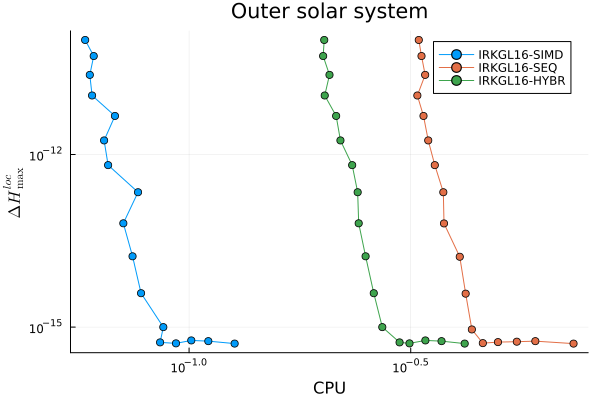

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [11]:
#
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb]
labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR"]

pl_=plot(title="Outer solar system", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL12 integrations (s=6)

In [12]:
ddt0_irk12=ddt0_irk16*3/4 
steps_irk12=tF./ddt0_irk12

println("simd:")
alg=IRKGL16(s=6, simd=true, fseq=false, second_order_ode=true)
sols_irk12_simd=run_many_IRKGL16(alg, prob, ddt0_irk12, HAM)
#
println("seq:")
alg=IRKGL16(s=6, simd=false, fseq=true, second_order_ode=true)
sols_irk12_seq=run_many_IRKGL16(alg,prob,ddt0_irk12,HAM)
#
println("hybrid:")
alg=IRKGL16(s=6, simd=true, fseq=true, second_order_ode=true)
sols_irk12_hyb=run_many_IRKGL16(alg,prob,ddt0_irk12,HAM);


simd:
,150.0,187.5,225.0,262.5,300.0,337.5,375.0,412.5,450.0,487.5,525.0,562.5,600.0,637.5,675.0,712.5,750.0
seq:
,150.0,187.5,225.0,262.5,300.0,337.5,375.0,412.5,450.0,487.5,525.0,562.5,600.0,637.5,675.0,712.5,750.0
hybrid:
,150.0,187.5,225.0,262.5,300.0,337.5,375.0,412.5,450.0,487.5,525.0,562.5,600.0,637.5,675.0,712.5,750.0


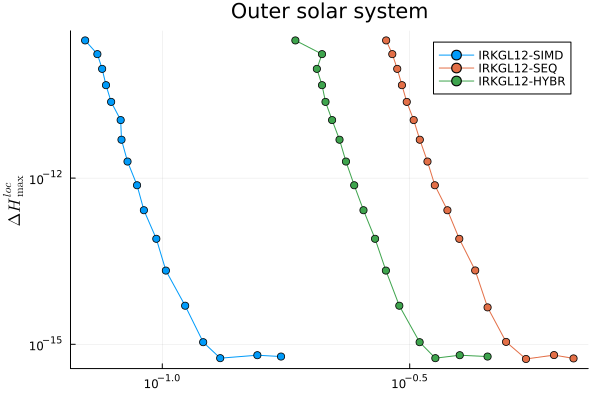

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [13]:
#
sols2plot=[sols_irk12_simd, sols_irk12_seq, sols_irk12_hyb]
labels2plot=["IRKGL12-SIMD", "IRKGL12-SEQ", "IRKGL12-HYBR"]

pl_=plot(title="Outer solar system",  ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL8 integrations (s=4)

In [14]:
ddt0_irk8=ddt0_irk16/2 
steps_irk8=tF./ddt0_irk8

println("simd:")
alg=IRKGL16(s=4, simd=true, fseq=false, second_order_ode=true)
sols_irk8_simd=run_many_IRKGL16(alg, prob, ddt0_irk8, HAM)
#
println("seq:")
alg=IRKGL16(s=4, simd=false, fseq=true, second_order_ode=true)
sols_irk8_seq=run_many_IRKGL16(alg,prob,ddt0_irk8,HAM)
#
println("hybrid:")
alg=IRKGL16(s=4, simd=true, fseq=true, second_order_ode=true)
sols_irk8_hyb=run_many_IRKGL16(alg,prob,ddt0_irk8,HAM);


simd:
,100.0,125.0,150.0,175.0,200.0,225.0,250.0,275.0,300.0,325.0,350.0,375.0,400.0,425.0,450.0,475.0,500.0
seq:
,100.0,125.0,150.0,175.0,200.0,225.0,250.0,275.0,300.0,325.0,350.0,375.0,400.0,425.0,450.0,475.0,500.0
hybrid:
,100.0,125.0,150.0,175.0,200.0,225.0,250.0,275.0,300.0,325.0,350.0,375.0,400.0,425.0,450.0,475.0,500.0


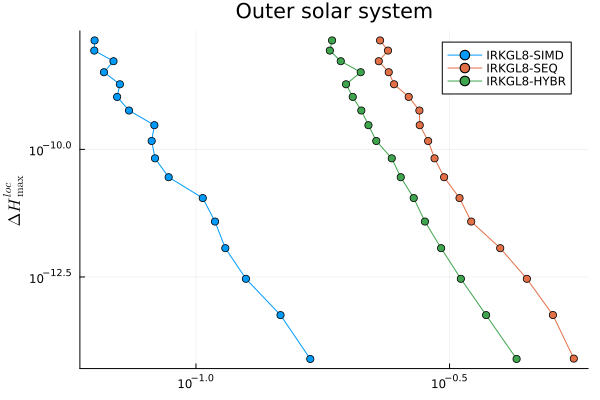

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [15]:
#
sols2plot=[sols_irk8_simd, sols_irk8_seq, sols_irk8_hyb]
labels2plot=["IRKGL8-SIMD", "IRKGL8-SEQ", "IRKGL8-HYBR"]

pl_=plot(title="Outer solar system",  ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL4 integrations (s=2)

In [16]:
ddt0_irk4=ddt0_irk16/4 
steps_irk4=tF./ddt0_irk4

println("simd:")
alg=IRKGL16(s=2, simd=true, fseq=false, second_order_ode=true)
sols_irk4_simd=run_many_IRKGL16(alg, prob, ddt0_irk4, HAM)
#
println("seq:")
alg=IRKGL16(s=2, simd=false, fseq=true, second_order_ode=true)
sols_irk4_seq=run_many_IRKGL16(alg,prob,ddt0_irk4,HAM);
#
println("hybrid:")
alg=IRKGL16(s=2, simd=true, fseq=true, second_order_ode=true)
sols_irk4_hyb=run_many_IRKGL16(alg,prob,ddt0_irk4,HAM);


simd:
,50.0,62.5,75.0,87.5,100.0,112.5,125.0,137.5,150.0,162.5,175.0,187.5,200.0,212.5,225.0,237.5,250.0
seq:
,50.0,62.5,75.0,87.5,100.0,112.5,125.0,137.5,150.0,162.5,175.0,187.5,200.0,212.5,225.0,237.5,250.0
hybrid:
,50.0,62.5,75.0,87.5,100.0,112.5,125.0,137.5,150.0,162.5,175.0,187.5,200.0,212.5,225.0,237.5,250.0


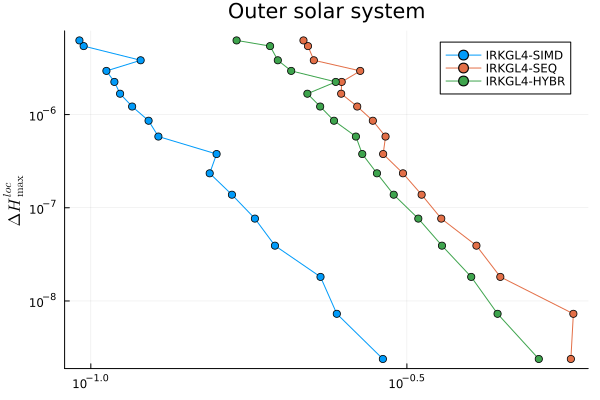

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [17]:
#
sols2plot=[sols_irk4_simd, sols_irk4_seq, sols_irk4_hyb]
labels2plot=["IRKGL4-SIMD", "IRKGL4-SEQ", "IRKGL4-HYBR"]

pl_=plot(title="Outer solar system",  ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

## Figures

In [38]:
sols2plot=[sols_irk16_simd, sols_irk16_seq,
           sols_irk12_simd, sols_irk12_seq,
           sols_irk8_simd, sols_irk8_seq,
           sols_irk4_simd, sols_irk4_seq
           ]

labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", 
             "IRKGL12-SIMD", "IRKGL12-SEQ",
             "IRKGL8-SIMD", "IRKGL8-SEQ",
             "IRKGL4-SIMD", "IRKGL4-SEQ"
]

labels2plot_=["IRKGL16", "IRKGL16", 
             "IRKGL12", "IRKGL12",
             "IRKGL8", "IRKGL8",
             "IRKGL4", "IRKGL4"
]

markershape2plot=[:circle, :xcross, :circle, :xcross, 
                  :circle, :xcross, :circle, :xcross]


ls2plot=[:solid, :solid, :solid, :solid, 
         :solid, :solid, :solid, :solid]

#colors2plot = [:red, :blue, :green, :orange, :purple, :cyan, :magenta, :teal, :gold]
colors2plot = [:red, :red, :blue, :blue, 
               :green, :green, :orange, :orange]

stages = [8,8,6,6,4,4,2,2];

### Figure3

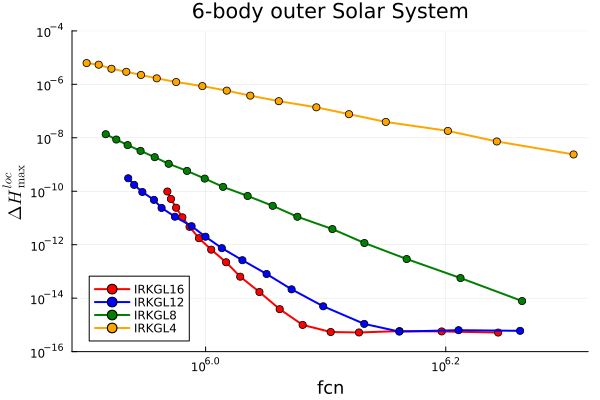

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [39]:
yrange=(1e-16, 1e-4)
pl3=plot(scale=:log10,
         ylimits=yrange,    
         title="6-body outer Solar System", 
         xlabel="fcn", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
         legend=:bottomleft,
         guidefont=font(12), labelsize=10)

for i in 1:2:length(sols2plot)
       
    sols=sols2plot[i]
    fcn=stages[i]*(sols.iters)
    #fcn=sols.fcns
    plot!(pl3, fcn , sols.MaxΔHlocal,
          markershape=:circle, lw=2,
          label=labels2plot_[i], color=colors2plot[i])
end

display(pl3)

In [40]:
savefig("./figures/Fig3.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-2-Efficiency comparison of s-stage IRKGL schemes/figures/Fig3.pdf"

### Figure4

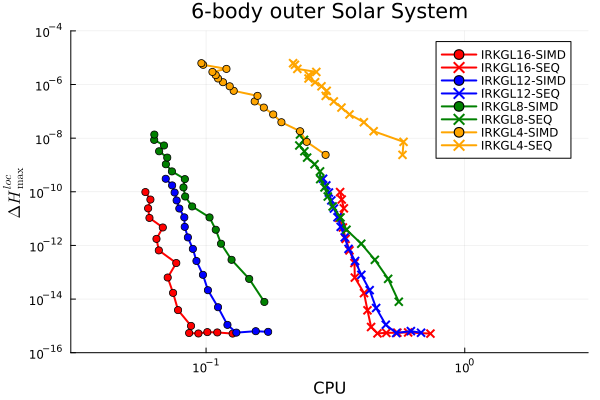

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [41]:
yrange=(1e-16, 1e-4)
xrange=(3e-2,3e0)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=markershape2plot[1], lw=2, ls=ls2plot[1],
          ylimits=yrange, xlimits=xrange,
          label=labels2plot[1], color=colors2plot[1],
          legend=:topright, #:bottomleft,
           title="6-body outer Solar System",
           xlabel="CPU",
           ylabel=L"\Delta H^{loc}_{\mathrm{max}}")

for i in 2:length(sols2plot)
    
    sols=sols2plot[i]
    
    plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
          markershape=markershape2plot[i], lw=2, ls=ls2plot[i],
          label=labels2plot[i], color=colors2plot[i],
          scale=:log10)
    
end

plot(pl1)



In [42]:
savefig("./figures/Fig4.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-2-Efficiency comparison of s-stage IRKGL schemes/figures/Fig4.pdf"